# Shared Prefix Sweep Benchmark Results

This notebook visualizes the benchmark results for shared prefix caching. The x-axis represents the prefix-cache usage rate (i.e. the sweep value) and the y-axis represents the median time-to-first-token (TTFT) in milliseconds.

Two metrics were swept:
- **Prefix Reuse Rate**: computed as `prompts_per_group / total_requests` (with total_requests fixed at 1024)
- **Prefix Length Ratio**: computed as `system_prompt_len / total_request_len` (with total_request_len fixed at 2176)

The two metrics intersect at the default values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

available_metrics = {
    "mean_e2e_latency_ms": "Mean E2E Latency (ms)",
    "median_e2e_latency_ms": "Median E2E Latency (ms)",
    "median_ttft_ms": "Median TTFT (ms)",
    "median_itl_ms": "Median ITL (ms)",
    "output_throughput": "Output Throughput (tokens/s)",
    "duration": "Benchmark Duration (s)",
}

In [2]:
def plot_metric(metric):
    # Load results from a single CSV file
    df = pd.read_csv('chosen_results.csv')
    df = df[df['gpu_type'] != 'gpu_type']
    df['sweep_value'] = pd.to_numeric(df['sweep_value'], errors='raise')
    df[metric] = pd.to_numeric(df[metric], errors='raise')

    # Separate data for the two sweep types
    df_prefix_reuse_rate = df[df['sweep_type'] == 'prefix_reuse_rate']
    df_prefix_length_ratio = df[df['sweep_type'] == 'prefix_length_ratio']

    if metric not in available_metrics:
        print("Invalid metric.")
        return

    # Plot the results
    plt.figure(figsize=(5, 3))
    plt.plot(df_prefix_reuse_rate['sweep_value'], df_prefix_reuse_rate[metric], marker='o', label='Prefix Reuse Rate')
    plt.plot(df_prefix_length_ratio['sweep_value'], df_prefix_length_ratio[metric], marker='s', label='Prefix Length Ratio')

    plt.ylim(0, None)
    plt.xlabel('Prefix-cache Usage Rate')
    plt.ylabel(available_metrics[metric])
    plt.title('Shared Prefix Benchmark Results')
    plt.legend()
    plt.grid(True)
    plt.show()

Plotting Mean E2E Latency (ms)


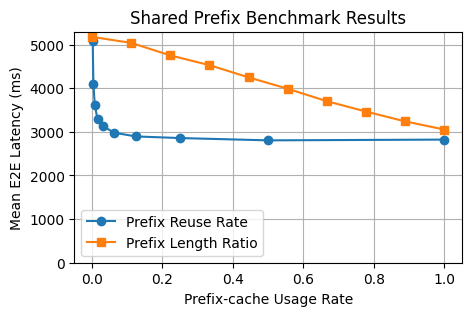

Plotting Median E2E Latency (ms)


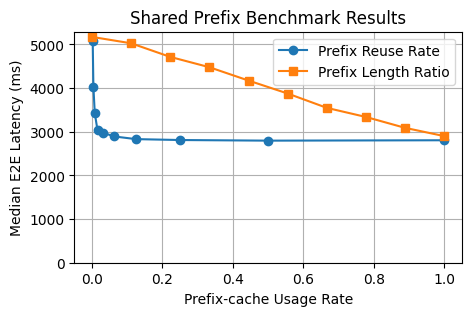

Plotting Median TTFT (ms)


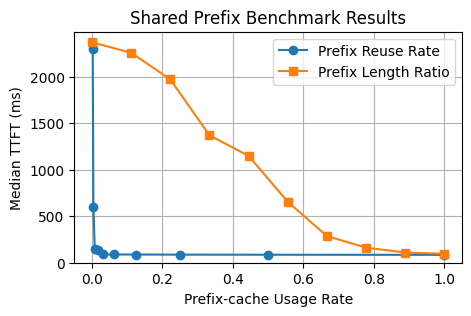

Plotting Median ITL (ms)


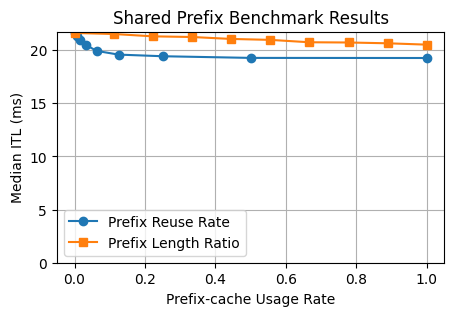

Plotting Output Throughput (tokens/s)


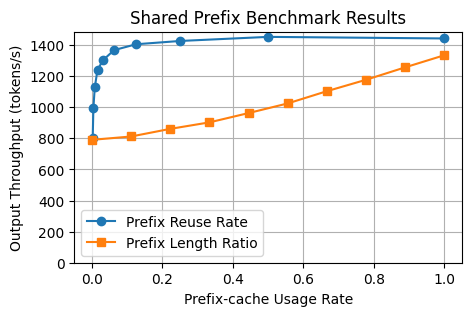

Plotting Benchmark Duration (s)


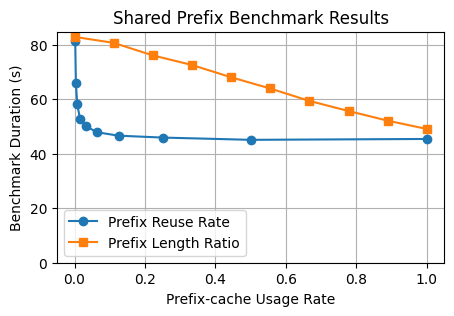

In [3]:
for metric in available_metrics:
    print(f"Plotting {available_metrics[metric]}")
    plot_metric(metric)